============================================================
# CELL 1: SETUP ENVIRONMENT
============================================================

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import os
import urllib.request

# Cek device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seed untuk reproduksibilitas
torch.manual_seed(42)
np.random.seed(42)

print("✅ Environment setup complete!")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
✅ Environment setup complete!
PyTorch version: 2.11.0+cpu


============================================================
# CELL 2: LOAD DATASET CIFAR-10
============================================================

  Mounting Google Drive...
Mounted at /content/drive
✅ Dataset folder found: /content/drive/MyDrive/dataset/cifar-10-batches/

CELL 2: LOAD CIFAR-10 FROM DRIVE

✅ CIFAR-10 Loaded!
   Training samples: 50000
   Testing samples: 10000

  Sample images from CIFAR-10:


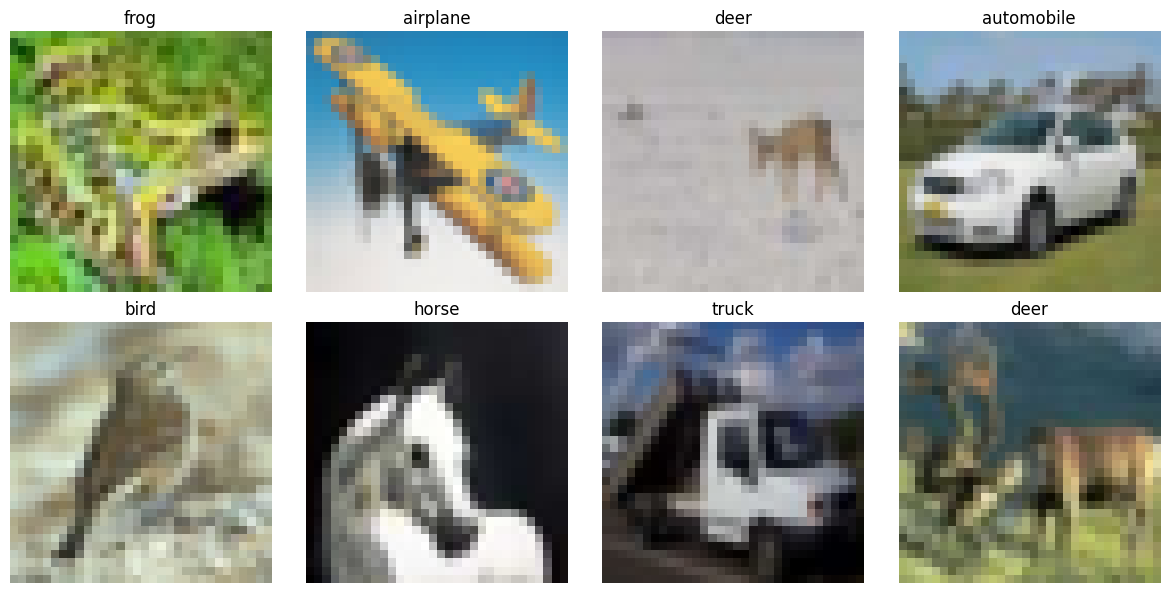


✅ CELL 2 COMPLETED!


In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle
from google.colab import drive

# Mount Google Drive
print("  Mounting Google Drive...")
drive.mount('/content/drive')

# ============================================================
# 1. Tentukan Path ke Dataset CIFAR-10 di Drive
# ============================================================

DATASET_PATH = '/content/drive/MyDrive/dataset/cifar-10-batches/'

# CIFAR-10 Batch files
TRAIN_BATCHES = ['data_batch_1', 'data_batch_2', 'data_batch_3', 'data_batch_4', 'data_batch_5']
TEST_BATCH = 'test_batch'

# Cek apakah folder ada
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"❌ Dataset folder tidak ditemukan di: {DATASET_PATH}")

print(f"✅ Dataset folder found: {DATASET_PATH}")

# ============================================================
# 2. Custom CIFAR-10 Dataset Class
# ============================================================

class CIFAR10Dataset(Dataset):
    def __init__(self, root_dir, batch_files, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.data = []
        self.targets = []

        for f in batch_files:
            file_path = os.path.join(self.root_dir, f)
            with open(file_path, 'rb') as fo:
                entry = pickle.load(fo, encoding='latin1')
                self.data.append(entry['data'])
                if 'labels' in entry:
                    self.targets.extend(entry['labels'])
                else:
                    self.targets.extend(entry['fine_labels'])

        self.data = np.vstack(self.data).reshape(-1, 3, 32, 32)
        self.data = self.data.transpose((0, 2, 3, 1))  # convert to HWC

        # Nama label CIFAR-10
        self.classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, target = self.data[idx], self.targets[idx]

        if self.transform:
            # Transformasi biasanya menerima PIL Image
            from PIL import Image
            img = Image.fromarray(img)
            img = self.transform(img)

        return img, target

# ============================================================
# 3. Fungsi Load Dataset
# ============================================================

def load_cifar10_dataset(batch_size=128):
    # Transformasi untuk CIFAR-10 (RGB)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Load dataset
    train_dataset = CIFAR10Dataset(DATASET_PATH, TRAIN_BATCHES, transform=transform)
    test_dataset = CIFAR10Dataset(DATASET_PATH, [TEST_BATCH], transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    print(f"\n✅ CIFAR-10 Loaded!")
    print(f"   Training samples: {len(train_dataset)}")
    print(f"   Testing samples: {len(test_dataset)}")

    return train_loader, test_loader, train_dataset, test_dataset

# ============================================================
# 4. EKSEKUSI
# ============================================================

print("\n" + "="*50)
print("CELL 2: LOAD CIFAR-10 FROM DRIVE")
print("="*50)

train_loader, test_loader, train_dataset, test_dataset = load_cifar10_dataset(batch_size=128)

# ============================================================
# 5. VISUALISASI SAMPLE
# ============================================================

def show_samples(loader, num_samples=8):
    images, labels = next(iter(loader))
    plt.figure(figsize=(12, 6))
    for i in range(min(num_samples, len(images))):
        plt.subplot(2, 4, i+1)
        # Denormalize
        img = images[i].numpy().transpose((1, 2, 0))
        img = (img * 0.5) + 0.5
        plt.imshow(img)
        plt.title(f"{train_dataset.classes[labels[i].item()]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("\n  Sample images from CIFAR-10:")
show_samples(train_loader)

print("\n✅ CELL 2 COMPLETED!")

============================================================
# CELL 3: CREATE RESNET-18 MODEL (ATAU TRAINING DARI AWAL)
============================================================

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from tqdm import tqdm
import time
import os
from google.colab import drive

# --- 1. Persiapan Path Drive ---
drive.mount('/content/drive')
model_dir = '/content/drive/MyDrive/model'
model_path = os.path.join(model_dir, 'resnet18_cifar10.pth')
os.makedirs(model_dir, exist_ok=True)

# --- 2. Load Dataset (CIFAR-10) ---
print("Menyiapkan dataset CIFAR-10 dari Drive...")

# Memastikan loader menggunakan 3 channel (RGB) sesuai CIFAR-10
train_loader, test_loader, train_dataset, test_dataset = load_cifar10_dataset(batch_size=128)
print(f"✅ Loader siap: {len(train_dataset)} training, {len(test_dataset)} testing samples.")

# --- 3. Definisi Model ResNet-18 ---
def get_resnet18_cifar10():
    # ResNet-18 default menerima 3 channel input
    model = models.resnet18(weights=None)
    # Sesuaikan output layer (fc) untuk 10 kelas
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 10)
    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_resnet18_cifar10().to(device)

# Variabel histori
training_history = {'loss': [], 'accuracy': []}

# --- 4. Cek Model di Drive ---
start_epoch = 0
if os.path.exists(model_path):
    print(f"\n✅ Menemukan model di {model_path}. Memuat model dan histori...")
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

    if 'history' in checkpoint:
        training_history = checkpoint['history']
        start_epoch = len(training_history['accuracy'])
        print(f"✅ Histori lengkap ditemukan ({start_epoch} epoch):")
        for i, (acc, loss) in enumerate(zip(training_history['accuracy'], training_history['loss'])):
            print(f"   Epoch {i+1}: Accuracy = {acc:.2f}%, Loss = {loss:.4f}")
    else:
        print("☑  Model dimuat tetapi data histori per epoch tidak ditemukan.")

# --- 5. Training Loop ---
num_epochs = 30

if start_epoch >= num_epochs:
    print(f"\nModel sudah dilatih selama {start_epoch} epoch. Melewati proses training.")
else:
    print(f"\nMemulai/Melanjutkan training ResNet-18 untuk CIFAR-10 dari epoch {start_epoch + 1}...")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(start_epoch, num_epochs):
        model.train()
        running_loss = 0.0
        pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch [{epoch+1}/{num_epochs}]")

        for batch_idx, (data, target) in pbar:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Evaluasi
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                outputs = model(data)
                _, predicted = torch.max(outputs.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total

        training_history['loss'].append(epoch_loss)
        training_history['accuracy'].append(epoch_acc)

        print(f'\nEpoch {epoch+1} selesai. Avg Loss: {epoch_loss:.4f}, Test Akurasi: {epoch_acc:.2f}%')

        # Simpan progres setiap epoch
        torch.save({
            'model_state_dict': model.state_dict(),
            'history': training_history
        }, model_path)

    print("\n✅ Model dan histori berhasil disimpan ke Drive!")

# Final Summary
if training_history['accuracy']:
    print(f"\n--- Ringkasan Training ResNet-18 (CIFAR-10) ---")
    print(f"Total Epoch: {len(training_history['accuracy'])}")
    print(f"Final Accuracy: {training_history['accuracy'][-1]:.2f}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Menyiapkan dataset CIFAR-10 dari Drive...

✅ CIFAR-10 Loaded!
   Training samples: 50000
   Testing samples: 10000
✅ Loader siap: 50000 training, 10000 testing samples.

✅ Menemukan model di /content/drive/MyDrive/model/resnet18_cifar10.pth. Memuat model dan histori...
✅ Histori lengkap ditemukan (30 epoch):
   Epoch 1: Accuracy = 54.62%, Loss = 1.3793
   Epoch 2: Accuracy = 66.74%, Loss = 0.9812
   Epoch 3: Accuracy = 68.20%, Loss = 0.7989
   Epoch 4: Accuracy = 70.74%, Loss = 0.6679
   Epoch 5: Accuracy = 72.20%, Loss = 0.5658
   Epoch 6: Accuracy = 73.47%, Loss = 0.5068
   Epoch 7: Accuracy = 73.73%, Loss = 0.3977
   Epoch 8: Accuracy = 74.66%, Loss = 0.3167
   Epoch 9: Accuracy = 73.84%, Loss = 0.2610
   Epoch 10: Accuracy = 74.24%, Loss = 0.2047
   Epoch 11: Accuracy = 75.25%, Loss = 0.1914
   Epoch 12: Accuracy = 76.38%, Loss = 0.1483
   Epoch 13: Accur

============================================================
# CELL 4: IMPLEMENTASI FGQ TERNARY QUANTIZATION
============================================================

## Fine-Grained Quantization Ternary

In [ ]:
def ternary_quantize_group(weight_tensor, group_size=4):
    """
    Melakukan ternary quantization per group (FGQ)

    Args:
        weight_tensor: Tensor bobot
        group_size (N): Jumlah bobot per kelompok

    Returns:
        ternary_weights: Bobot ternary {-alpha, 0, +alpha}
        alphas: Faktor skala per kelompok
    """
    original_shape = weight_tensor.shape
    flat_weights = weight_tensor.flatten()
    n = flat_weights.numel()

    ternary_flat = torch.zeros_like(flat_weights)
    alphas = []

    for i in range(0, n, group_size):
        group = flat_weights[i:min(i+group_size, n)]
        group_size_actual = len(group)

        if group_size_actual == 0:
            continue

        abs_group = torch.abs(group)

        # Jika semua bobot 0
        if abs_group.max().item() == 0:
            alphas.append(0.0)
            continue

        # Cari threshold optimal (20 kandidat)
        thresholds = torch.linspace(
            abs_group.min().item(),
            abs_group.max().item(),
            steps=20
        )

        best_delta = 0
        best_score = -float('inf')

        for delta in thresholds:
            mask = abs_group > delta
            if mask.sum() == 0:
                continue
            sum_abs = abs_group[mask].sum()
            count = mask.sum().float()
            score = (sum_abs ** 2) / count
            if score > best_score:
                best_score = score
                best_delta = delta

        # Hitung alpha
        mask = abs_group > best_delta
        if mask.sum() == 0:
            alphas.append(0.0)
            continue

        alpha = abs_group[mask].sum() / mask.sum().float()
        alphas.append(alpha.item())

        # Buat ternary weights
        ternary_group = torch.zeros_like(group)
        ternary_group[group > best_delta] = alpha
        ternary_group[group < -best_delta] = -alpha

        ternary_flat[i:min(i+group_size, n)] = ternary_group

    return ternary_flat.reshape(original_shape), alphas

def apply_fgq_to_model(model, group_size=4, verbose=True):
    """
    Menerapkan FGQ ke semua layer konvolusi dan linear
    """
    print(f"\n🔧 Applying FGQ with N={group_size}...")
    alpha_means = []
    layer_names = []
    total_params = 0

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            original_weight = module.weight.data
            total_params += original_weight.numel()

            ternary_weight, alphas = ternary_quantize_group(
                original_weight,
                group_size=group_size
            )
            module.weight.data = ternary_weight

            alpha_mean = np.mean(alphas) if alphas else 0
            alpha_means.append(alpha_mean)
            layer_names.append(name)

            if verbose:
                num_groups = original_weight.numel() // group_size if group_size > 0 else 0
                print(f"  ✓ {name}: {original_weight.shape}, "
                      f"groups={num_groups}, α_mean={alpha_mean:.4f}")

    print(f"   Total parameters quantized: {total_params:,}")
    return model, alpha_means, layer_names

print("\n" + "="*50)
print("CELL 5: FGQ IMPLEMENTATION READY")
print("="*50)

print("✅ FGQ functions defined!")
print("   - ternary_quantize_group(): quantize per group")
print("   - apply_fgq_to_model(): apply to entire model")


CELL 5: FGQ IMPLEMENTATION READY
✅ FGQ functions defined!
   - ternary_quantize_group(): quantize per group
   - apply_fgq_to_model(): apply to entire model


## Standard Quantization Ternary

In [ ]:
def standard_ternary_quantize(weight_tensor):
    """
    Melakukan standard ternary quantization pada seluruh tensor bobot
    (Global quantization, bukan per group/fine-grained)
    """
    original_shape = weight_tensor.shape
    flat_weights = weight_tensor.flatten()
    abs_weights = torch.abs(flat_weights)

    # Jika semua bobot 0
    if abs_weights.max().item() == 0:
        return torch.zeros_like(weight_tensor), 0.0

    # Mencari threshold optimal secara global (berdasarkan rata-rata absolut)
    # Metode umum: delta = 0.7 * E[|W|]
    delta = 0.7 * torch.mean(abs_weights)

    # Hitung mask untuk nilai yang lebih besar dari threshold
    mask = abs_weights > delta

    if mask.sum() == 0:
        return torch.zeros_like(weight_tensor), 0.0

    # Hitung alpha (skala) global
    alpha = abs_weights[mask].sum() / mask.sum().float()

    # Buat ternary weights
    ternary_flat = torch.zeros_like(flat_weights)
    ternary_flat[flat_weights > delta] = alpha
    ternary_flat[flat_weights < -delta] = -alpha

    return ternary_flat.reshape(original_shape), alpha.item()

def apply_standard_ternary_to_model(model, verbose=True):
    """
    Menerapkan Standard Ternary Quantization ke semua layer konvolusi dan linear
    """
    print(f"\n🔧 Applying Standard Ternary Quantization (Global)...")
    layer_alphas = []

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            original_weight = module.weight.data

            ternary_weight, alpha = standard_ternary_quantize(original_weight)
            module.weight.data = ternary_weight

            layer_alphas.append(alpha)

            if verbose:
                print(f"  ✓ {name}: {original_weight.shape}, α={alpha:.4f}")

    return model, layer_alphas

print("\n" + "="*50)
print("CELL 5.1: STANDARD TERNARY QUANTIZATION READY")
print("="*50)
print("✅ Standard Ternary functions defined!")


CELL 5.1: STANDARD TERNARY QUANTIZATION READY
✅ Standard Ternary functions defined!


============================================================
# CELL 5: SKENARIO A - DENGAN STANDARD QUANTIZATION
============================================================


CELL 7: SKENARIO C - STANDARD TERNARY QUANTIZATION
📊 Mengambil Baseline Accuracy dari model ResNet-18 di memori...

📊 Baseline accuracy (FP32): 75.82%
📊 Baseline accuracy (FP32): 75.82%

🔧 Applying Standard Ternary Quantization (Global)...
  ✓ conv1: torch.Size([64, 3, 7, 7]), α=0.1172
  ✓ layer1.0.conv1: torch.Size([64, 64, 3, 3]), α=0.1343
  ✓ layer1.0.conv2: torch.Size([64, 64, 3, 3]), α=0.1372
  ✓ layer1.1.conv1: torch.Size([64, 64, 3, 3]), α=0.1361
  ✓ layer1.1.conv2: torch.Size([64, 64, 3, 3]), α=0.1374
  ✓ layer2.0.conv1: torch.Size([128, 64, 3, 3]), α=0.1287
  ✓ layer2.0.conv2: torch.Size([128, 128, 3, 3]), α=0.1300
  ✓ layer2.0.downsample.0: torch.Size([128, 64, 1, 1]), α=0.1938
  ✓ layer2.1.conv1: torch.Size([128, 128, 3, 3]), α=0.1299
  ✓ layer2.1.conv2: torch.Size([128, 128, 3, 3]), α=0.1296
  ✓ layer3.0.conv1: torch.Size([256, 128, 3, 3]), α=0.1247
  ✓ layer3.0.conv2: torch.Size([256, 256, 3, 3]), α=0.1204
  ✓ layer3.0.downsample.0: torch.Size([256, 128, 1, 1]), α=0.1622


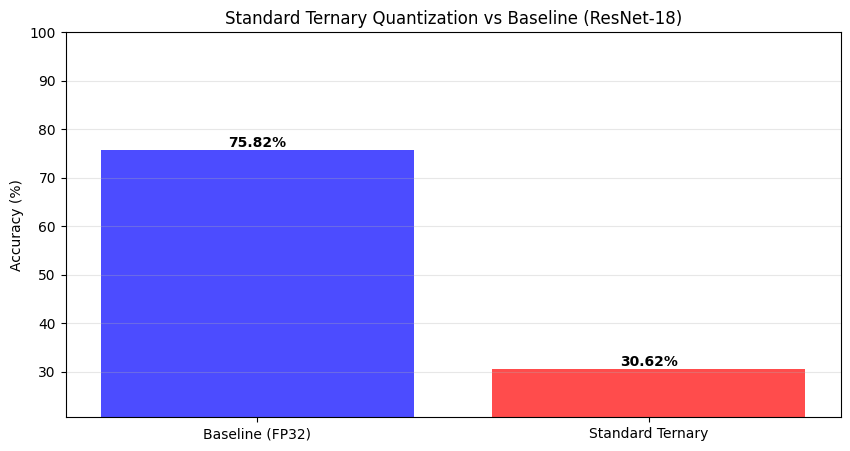


----------------------------------------
📝 Technical Summary:
   - Quantization Level: 2-bit (Ternary)
   - Granularity: Global (Per Layer)
   - Final Accuracy: 30.62%
   - Accuracy Drop: 45.20%
----------------------------------------

✅ CELL 7 COMPLETED!


In [ ]:
print("\n" + "="*50)
print("CELL 7: SKENARIO C - STANDARD TERNARY QUANTIZATION")
print("="*50)

from torchvision.models.resnet import resnet18
def evaluate_accuracy(model, data_loader, verbose=False):
    """
    Evaluasi akurasi model
    """
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100.0 * correct / total
    return accuracy

# --- Persiapan Baseline ---
# Mengambil model yang sudah terlatih di memori (ResNet-18 dari Cell 3)
print("📊 Mengambil Baseline Accuracy dari model ResNet-18 di memori...")
baseline_acc = evaluate_accuracy(model, test_loader)

# Simpan state awal untuk reset selama testing
import copy
baseline_state = copy.deepcopy(model.state_dict())

print(f"\n📊 Baseline accuracy (FP32): {baseline_acc:.2f}%")

# 1. Pastikan baseline model dari Cell 6 sudah tersedia
try:
    print(f"📊 Baseline accuracy (FP32): {baseline_acc:.2f}%")

    # Inisialisasi model ResNet-18 dan muat state baseline
    model_st = get_resnet18_cifar10().to(device)
    model_st.load_state_dict(baseline_state)
    model_st.eval()

    # 2. Terapkan Standard Ternary Quantization (Global)
    model_st, layer_alphas = apply_standard_ternary_to_model(model_st, verbose=True)

    # 3. Evaluasi Akurasi
    print("\n📊 Evaluating Standard Ternary model...")
    acc_st = evaluate_accuracy(model_st, test_loader, verbose=False)

    drop_st = baseline_acc - acc_st

    print(f"\n✅ Standard Ternary Top-1 Accuracy: {acc_st:.2f}%")
    print(f"   Drop from baseline: {drop_st:.2f}%")

    # 4. Visualisasi Perbandingan (Standard vs Baseline)
    plt.figure(figsize=(10, 5))
    labels = ['Baseline (FP32)', 'Standard Ternary']
    accuracies = [baseline_acc, acc_st]
    colors = ['blue', 'red']

    plt.bar(labels, accuracies, color=colors, alpha=0.7)
    plt.ylabel('Accuracy (%)')
    plt.title('Standard Ternary Quantization vs Baseline (ResNet-18)')
    plt.ylim(max(0, min(accuracies) - 10), 100)
    plt.grid(True, axis='y', alpha=0.3)

    for i, acc in enumerate(accuracies):
        plt.text(i, acc + 0.5, f"{acc:.2f}%", ha='center', fontweight='bold')

    plt.show()

    # 5. Ringkasan Teknis
    print("\n" + "-"*40)
    print(f"📝 Technical Summary:")
    print(f"   - Quantization Level: 2-bit (Ternary)")
    print(f"   - Granularity: Global (Per Layer)")
    print(f"   - Final Accuracy: {acc_st:.2f}%")
    print(f"   - Accuracy Drop: {drop_st:.2f}%")
    print("-"*40)

except NameError:
    print("❌ ERROR: Variabel 'baseline_acc' atau 'baseline_state' tidak ditemukan.")
    print("💡 Silakan jalankan CELL 6 sampai selesai terlebih dahulu sebelum menjalankan sel ini.")

print("\n✅ CELL 7 COMPLETED!")

============================================================
# CELL 6: SKENARIO B - DENGAN FINE-GRAINED QUANTIZATION ============================================================

In [ ]:
# Test dengan berbagai group size
group_sizes = [2, 4, 8, 16, 32, 64]
results = {'N': [], 'accuracy': [], 'drop': [], 'alpha_means': []}

for N in group_sizes:
    print(f"\n{'='*40}")
    print(f"Testing N = {N}")
    print(f"{'='*40}")

    # FIXED: Gunakan fungsi kustom get_resnet18_cifar() agar struktur layer sesuai
    test_model = get_resnet18_cifar10().to(device)
    test_model.load_state_dict(baseline_state)
    test_model.eval()

    # Apply FGQ
    test_model, alpha_means, layer_names = apply_fgq_to_model(test_model, group_size=N, verbose=True)

    # Evaluasi
    print("\n📊 Evaluating FGQ model (without fine-tuning)...")
    acc = evaluate_accuracy(test_model, test_loader, verbose=True)

    drop = baseline_acc - acc
    print(f"\n✅ FGQ N={N} Top-1 Accuracy: {acc:.2f}%")
    print(f"   Drop from baseline: {drop:.2f}%")

    results['N'].append(N)
    results['accuracy'].append(acc)
    results['drop'].append(drop)
    results['alpha_means'].append(alpha_means)

# Visualisasi hasil
plt.figure(figsize=(15, 5))

# Plot 1: Accuracy vs Group Size
plt.subplot(1, 3, 1)
plt.plot(results['N'], results['accuracy'], marker='o', linewidth=2, markersize=10)
plt.axhline(y=baseline_acc, color='r', linestyle='--',
            label=f'Baseline ({baseline_acc:.1f}%)')
plt.xlabel('Group Size (N)')
plt.ylabel('Accuracy (%)')
plt.title('FGQ: Accuracy vs Group Size (ResNet-18)')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: Drop in Accuracy
plt.subplot(1, 3, 2)
plt.bar([str(n) for n in results['N']], results['drop'], color='orange', alpha=0.7)
plt.xlabel('Group Size (N)')
plt.ylabel('Accuracy Drop (%)')
plt.title('Accuracy Drop from Baseline')
plt.grid(True, alpha=0.3, axis='y')

# Plot 3: Alpha Mean per Layer (N=4, index 1)
plt.subplot(1, 3, 3)
if len(results['alpha_means']) > 1:
    alpha_means_4 = results['alpha_means'][1]  # Index 1 untuk N=4
    plt.bar(range(len(alpha_means_4)), alpha_means_4, alpha=0.7, color='green')
    plt.xlabel('Layer Index')
    plt.ylabel('alpha_mean')
    plt.title(f'Alpha Mean per Layer (N=4)')
    plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✅ CELL 6 COMPLETED!")


Testing N = 2

🔧 Applying FGQ with N=2...
  ✓ conv1: torch.Size([64, 3, 7, 7]), groups=4704, α_mean=0.1035
  ✓ layer1.0.conv1: torch.Size([64, 64, 3, 3]), groups=18432, α_mean=0.1255
  ✓ layer1.0.conv2: torch.Size([64, 64, 3, 3]), groups=18432, α_mean=0.1290
  ✓ layer1.1.conv1: torch.Size([64, 64, 3, 3]), groups=18432, α_mean=0.1284
  ✓ layer1.1.conv2: torch.Size([64, 64, 3, 3]), groups=18432, α_mean=0.1300
  ✓ layer2.0.conv1: torch.Size([128, 64, 3, 3]), groups=36864, α_mean=0.1215
  ✓ layer2.0.conv2: torch.Size([128, 128, 3, 3]), groups=73728, α_mean=0.1239
  ✓ layer2.0.downsample.0: torch.Size([128, 64, 1, 1]), groups=4096, α_mean=0.1854
  ✓ layer2.1.conv1: torch.Size([128, 128, 3, 3]), groups=73728, α_mean=0.1235
  ✓ layer2.1.conv2: torch.Size([128, 128, 3, 3]), groups=73728, α_mean=0.1234
  ✓ layer3.0.conv1: torch.Size([256, 128, 3, 3]), groups=147456, α_mean=0.1188
  ✓ layer3.0.conv2: torch.Size([256, 256, 3, 3]), groups=294912, α_mean=0.1141
  ✓ layer3.0.downsample.0: torch.Siz

============================================================
# CELL 7: PERBANDINGAN SKENARIO A vs B
============================================================

In [ ]:
print("\n" + "="*50)
print("CELL 7: PERBANDINGAN AKURASI TERBAIK")
print("="*50)

# Ambil akurasi terbaik dari FGQ
best_fgq_acc = max(results['accuracy'])
best_n = results['N'][results['accuracy'].index(best_fgq_acc)]

# Data untuk bar chart
labels = ['Baseline (FP32)', 'Standard Ternary', f'Best FGQ (N={best_n})']
values = [baseline_acc, acc_st, best_fgq_acc]
colors = ['#2ecc71', '#e74c3c', '#3498db']

plt.figure(figsize=(10, 6))

# Membuat bar chart
bars = plt.bar(labels, values, color=colors, alpha=0.8, width=0.6)

# Dekorasi Plot
plt.ylabel('Top-1 Accuracy (%)')
plt.title('Perbandingan Akurasi: Baseline vs Standard vs Best Fine-Grained')
plt.ylim(max(0, min(values) - 5), 100)
plt.grid(True, axis='y', alpha=0.3, linestyle='--')

# Tambahkan label nilai di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# --- Insight & Kesimpulan ---
print("\n" + "="*50)
print("RINGKASAN PERBANDINGAN")
print("="*50)

print(f"1. Akurasi Baseline (FP32)  : {baseline_acc:.2f}%")
print(f"2. Akurasi Standard Ternary : {acc_st:.2f}% (Drop: {baseline_acc - acc_st:.2f}%)")
print(f"3. Akurasi Terbaik FGQ (N={best_n}): {best_fgq_acc:.2f}% (Drop: {baseline_acc - best_fgq_acc:.2f}%)")

print("\n💡 Kesimpulan Utama:")
print(f"✔ FGQ dengan N={best_n} memberikan hasil yang paling mendekati model asli (FP32).")
print("✔ Bar chart di atas menunjukkan bahwa pendekatan Fine-Grained jauh lebih efektif")
print("   dalam mempertahankan akurasi dibandingkan pendekatan Standard (Global) pada level ternary.")

print("\n✅ ANALISIS PERBANDINGAN SELESAI!")